# ROAD SEGMENTATION

In [ ]:
'''
Fragment to try on : 
# 11545_sat
# 14361_sat
# 4227_sat
# 5279_sat
# 17193_sat

 Classical road segmentation on aerial map.

    Pipeline:
      1. CLAHE on L(lightness) channel (LAB) — normalize lighting , improve contrast 
      2. HSV threshold — roads: low saturation, mid brightness (gray-ish)
      3. Morphological close — fill gaps in road interiors
      4. Morphological open  — remove small noise blobs
      5. Contour filter — keep only large or elongated regions


      
CLAHE (Contrast Limited Adaptive Histogram Equalization)  - works by dividing img to smaller 
& adjust contrast in each part, helps in avoiding too bright or too dark
    parameters : Cliplimit ( threshold for contrast limiting : default - 40)
    titleGridSize : sets no of rows and columns ( deafaul t; 8 * 8)

LAB - Lightness [0-255], (Green -Red)[+ve : R, -ve: G] , (Blue-Yellow)[+ve : Y, -ve: B]
Need of LAB ??
'''




In [2]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [61]:
img = cv2.imread("DeepGlobe_Dataset/train/11545_sat.jpg")
#img = cv2.imread("DeepGlobe_Dataset/train/17193_sat.jpg")

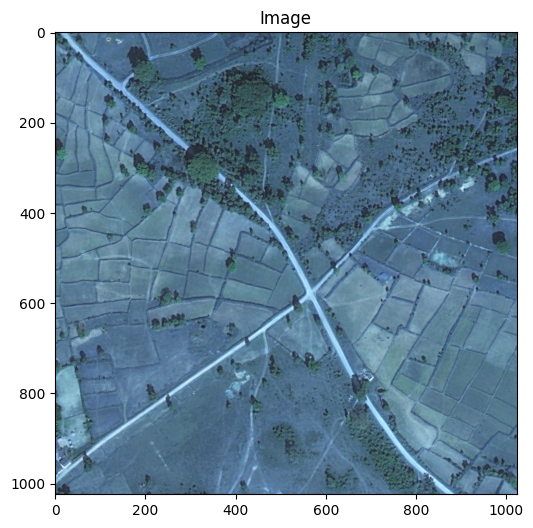

In [62]:
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Image")
plt.show()

In [63]:
# CLAHE equalisation
lab      = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b  = cv2.split(lab)
clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
l_eq     = clahe.apply(l)
img_eq   = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)



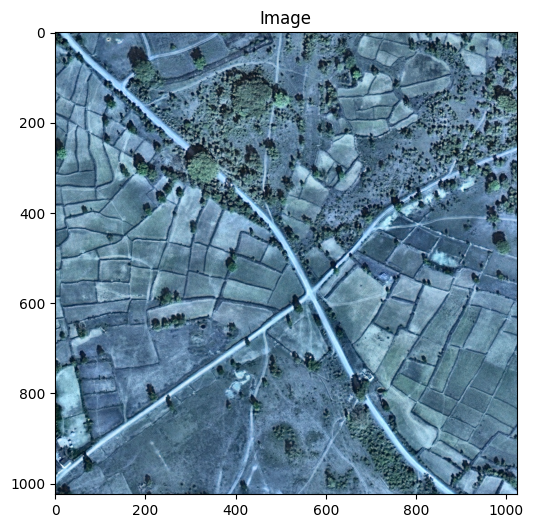

In [64]:
plt.figure(figsize=(10, 6))
plt.imshow(img_eq)
plt.title("Image")
plt.show()

In [65]:
# HSV Threshold 
hsv = cv2.cvtColor(img_eq, cv2.COLOR_BGR2HSV)
lower = np.array([7,97, 193 ]) #ROAD_VAL_MIN])
upper = np.array([89, 255, 255]) #ROAD_SAT_MAX, ROAD_VAL_MAX])
mask = cv2.inRange(hsv, lower, upper)

In [66]:
# use slider detect hsv lower and upper 

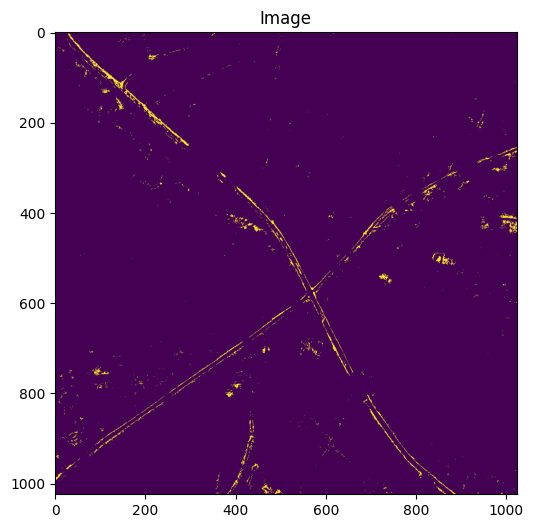

In [67]:
plt.figure(figsize=(10, 6))
plt.imshow(mask)
plt.title("Image")
plt.show()

In [26]:
# bridge/close small gaps 
k_close = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=2)

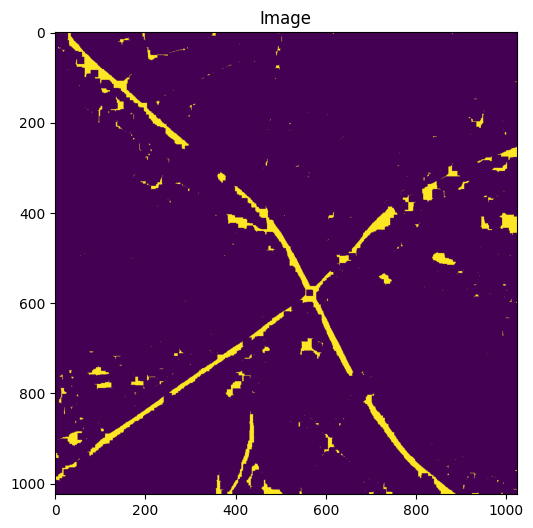

In [27]:
plt.figure(figsize=(10, 6))
plt.imshow(mask)
plt.title("Image")
plt.show()

In [28]:
# remove noise 
k_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k_open, iterations=1)

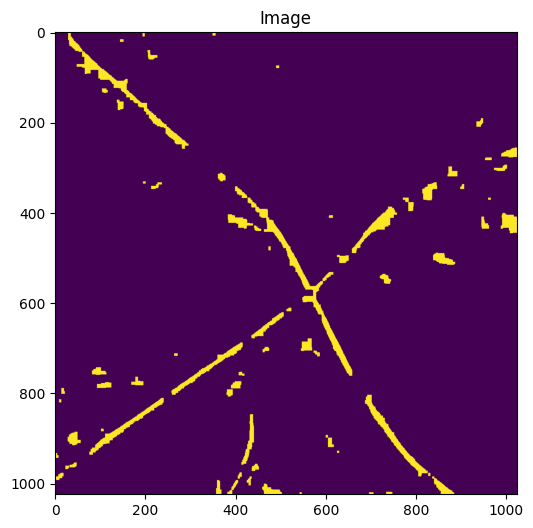

In [29]:
plt.figure(figsize=(10, 6))
plt.imshow(mask)
plt.title("Image")
plt.show()

In [43]:
# contour  filter - keep large or enlongated shapes
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
filtered = np.zeros_like(mask)
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 25:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    aspect = max(w, h) / (min(w, h) + 1e-5)
    if area > 3000 or aspect < 1:
        cv2.drawContours(filtered, [cnt], -1, 255, -1)


road_mask = filtered



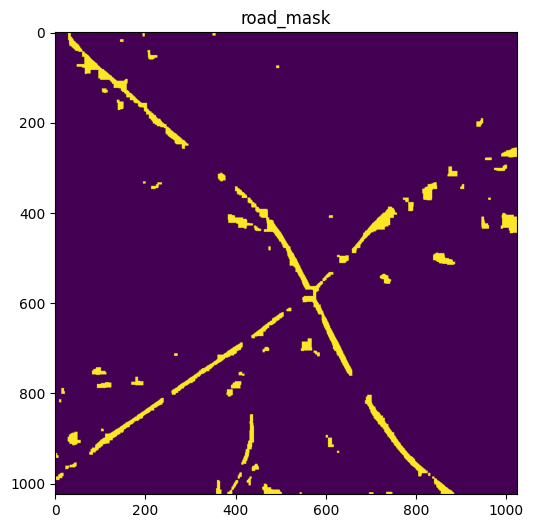

In [44]:
plt.figure(figsize=(10, 6))
plt.imshow(mask)
plt.title("road_mask")
plt.show()

#### research on U-Net Road Segmentation Model 

In [ ]:
# METHOD 1 — Adaptive Thresholding (Auto HSV)
# METHOD 2 — K-Means Clustering
# METHOD 3 — Histogram-Based Auto Threshold
# METHOD 4 - Watershed Algorithm
# METHOD 5 - MeanShift Filtering: Use cv2.pyrMeanShiftFiltering to smooth the image while preserving edges, which helps in grouping similar road pixels together.



Adaptive thresholding - algorithm determines the threshold for a pixel based on a small region around it. 
- different threshold for differnet regions of same image 
cv.adaptiveThreshold - 
INPUT PARAMETERS : 
adaptive mean 
adaptive gaussian_c

- 

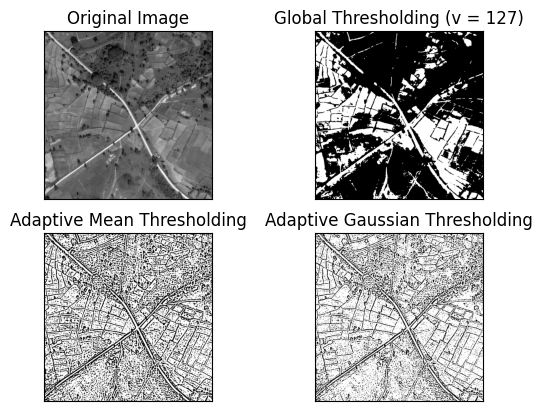

In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

img = cv.imread("DeepGlobe_Dataset/train/11545_sat.jpg", cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img = cv.medianBlur(img,5)

ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)

titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]

for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

Histogram-Based Auto Threshold
----------------------------------------------------------------------
- Ostu's Method
- Triangle Method
- IsoData (Iterative Selection)
- Minimum
- Maximum Entropy (Kapur)
- Balanced Histogram Threshold (BHT)
- Yen Method

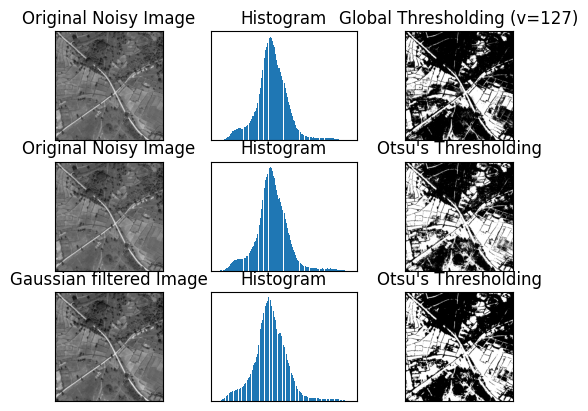

In [2]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
 
img = cv.imread("DeepGlobe_Dataset/train/11545_sat.jpg", cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
 
# global thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
 
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
 
# Otsu's thresholding after Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
 
# plot all the images and their histograms
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
          'Original Noisy Image','Histogram',"Otsu's Thresholding",
          'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]
 
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

generalise : no hsv - no assumption

- superpixels (SLIC) - break img into meaningful region
- color + texture scoring -> find road -like regions 
- Graph Connectivity -> keep only continois regions
- Morphology + smoothing - clean final mask 

Segment 0: mean=205.60, std=22.17, pixels=3868
Segment 1: mean=64.69, std=6.54, pixels=57966
Segment 2: mean=118.41, std=7.48, pixels=92722
Segment 3: mean=80.84, std=4.60, pixels=128467
Segment 4: mean=96.20, std=5.43, pixels=135193
Segment 5: mean=148.10, std=9.91, pixels=61784


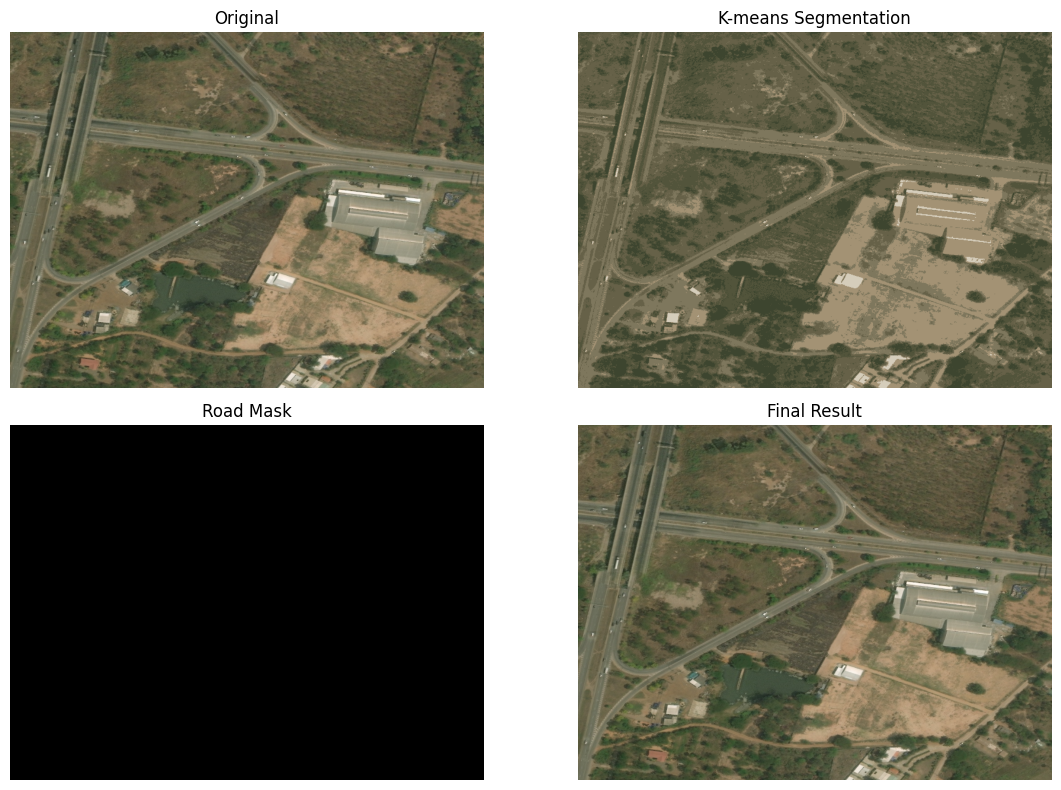

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def road_segmentation_advanced(img_path, K=6, debug=False):
    # 1. Load + Resize
    
    img = cv2.imread(img_path)
    if img is None:
        print("Error loading image")
        return None

    img = cv2.resize(img, (800, 600))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. K-means segmentation
    
    Z = img.reshape((-1, 3))
    Z = np.float32(Z)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 15, 1.0)

    _, labels, centers = cv2.kmeans(
        Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS
    )

    centers = np.uint8(centers)
    labels = labels.reshape(img.shape[:2])

    # Visualization of segmentation
    segmented = centers[labels.flatten()].reshape(img.shape)

    
    # 3. Segment scoring
    mask = np.zeros(labels.shape, dtype=np.uint8)

    best_score = float('inf')
    best_k = -1

    for k in range(K):
        segment_mask = (labels == k)

        seg_pixels = img[segment_mask]
        seg_gray = gray[segment_mask]

        if len(seg_pixels) < 500:
            continue

        mean_intensity = np.mean(seg_gray)
        std_texture = np.std(seg_gray)

        if debug:
            print(f"Segment {k}: mean={mean_intensity:.2f}, std={std_texture:.2f}, pixels={len(seg_pixels)}")

        # Road-like heuristic
        if 60 < mean_intensity < 200 and std_texture < 60:
            mask[segment_mask] = 255

        # fallback scoring (low texture = good)
        if std_texture < best_score:
            best_score = std_texture
            best_k = k

    
    # 4. Fallback if empty
    if np.sum(mask) == 0 and best_k != -1:
        print(" Fallback activated")
        mask[labels == best_k] = 255

    # 5. Edge reinforcement
    
    edges = cv2.Canny(gray, 50, 150)
    mask = cv2.bitwise_or(mask, edges)

    # 6. Morphological cleanup
    kernel = np.ones((7, 7), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # 7. Keep largest connected region
    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask)

    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        final_mask = np.zeros_like(mask)
        final_mask[labels_cc == largest] = 255
    else:
        final_mask = mask

    # 8. Smooth mask
    final_mask = cv2.GaussianBlur(final_mask, (5, 5), 0)

    # 9. Apply mask
    result = cv2.bitwise_and(img, img, mask=final_mask)

    return img, segmented, final_mask, result


# RUN
img, segmented, mask, result = road_segmentation_advanced(
    "DeepGlobe_Dataset/train/17193_sat.jpg",
    K=6,
    debug=True
)

# DISPLAY

plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
plt.title("K-means Segmentation")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(mask, cmap='gray')
plt.title("Road Mask")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Final Result")
plt.axis('off')

plt.tight_layout()
plt.show()

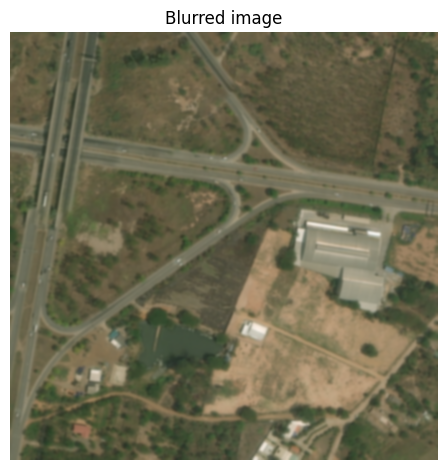

In [50]:
img = cv2.imread("DeepGlobe_Dataset/train/17193_sat.jpg")
blur = cv2.GaussianBlur(img, (15, 15), 0)
plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
plt.title("Blurred image")
plt.axis('off')
plt.tight_layout()
plt.show()